# Import data

In [10]:
#!/bin/bash
!curl -L -o pediatric-chest-xray-pneumonia-balanced-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/yusufmurtaza01/pediatric-chest-xray-pneumonia-balanced-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1703M  100 1703M    0     0  5428k      0  0:05:21  0:05:21 --:--:-- 6611k 2345k      0  0:12:23  0:00:02  0:12:21 2575k  0  0:08:54  0:00:24  0:08:30 5326k  0     0  4465k      0  0:06:30  0:00:55  0:05:35 5654k  0  4550k      0  0:06:23  0:01:04  0:05:19 4652k   0  0:06:11  0:01:49  0:04:22 4545k  0  0:06:26  0:02:16  0:04:10 4996k   0     0  4605k      0  0:06:18  0:02:30  0:03:48 5363k   0  0:06:07  0:02:55  0:03:12 5344kM    0     0  4787k      0  0:06:04  0:03:05  0:02:59 5340k 0  4917k      0  0:05:54  0:03:29  0:02:25 6354k   0  5063k      0  0:05:44  0:03:58  0:01:46 6113k 1205M    0     0  5064k      0  0:05:44  0:04:03  0:01:41 5097k0  0:05:35  0:04:29  0:01:06 5821k    0  0:05:32  0:04:37  0:00:55 6625k 0  0:05:30  0:04:43  0:00:47 6847k

In [11]:
import zipfile, io, random, numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


# Load dataset from zip

In [12]:
class ZipXrayDataset(Dataset):
    """Streams images directly from the zip file — no extraction needed."""

    def __init__(self, zip_path, transform=None):
        self.zip_path = zip_path
        self.transform = transform
        self.samples = []  # (filename, label)

        with zipfile.ZipFile(zip_path, "r") as zf:
            for name in zf.namelist():
                if not name.lower().endswith((".jpeg", ".jpg", ".png")):
                    continue
                if name.startswith("NORMAL/"):
                    self.samples.append((name, 0))
                elif name.startswith("PNEUMONIA/"):
                    self.samples.append((name, 1))

        print(f"Loaded {len(self.samples)} images  |  "
              f"NORMAL: {sum(1 for _, l in self.samples if l == 0)}  |  "
              f"PNEUMONIA: {sum(1 for _, l in self.samples if l == 1)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        with zipfile.ZipFile(self.zip_path, "r") as zf:
            img = Image.open(io.BytesIO(zf.read(fname))).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [13]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

full_dataset = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip")

# 80 / 10 / 10 split
n = len(full_dataset)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val

torch.manual_seed(42)
train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test])

# Apply different transforms to each split
train_ds.dataset = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip", transform=train_transform)
val_ds.dataset   = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip", transform=val_transform)
test_ds.dataset  = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Train: 6824  |  Val: 853  |  Test: 853


# Build model (ResNet-18 transfer learning)

In [14]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze early layers, fine-tune later layers
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier head for binary classification
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 1),
)

model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/kaisarthik/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.33MB/s]


Trainable params: 8,394,241


# Train

In [15]:
NUM_EPOCHS = 10
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)
            logits = model(imgs).squeeze(1)
            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(logits) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += imgs.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  "
          f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

Epoch 1/10  train_loss=0.1292  train_acc=0.9516  val_loss=0.0902  val_acc=0.9660
Epoch 2/10  train_loss=0.0715  train_acc=0.9741  val_loss=0.0833  val_acc=0.9719
Epoch 3/10  train_loss=0.0604  train_acc=0.9793  val_loss=0.0741  val_acc=0.9719
Epoch 4/10  train_loss=0.0500  train_acc=0.9812  val_loss=0.1243  val_acc=0.9519
Epoch 5/10  train_loss=0.0426  train_acc=0.9843  val_loss=0.0747  val_acc=0.9707
Epoch 6/10  train_loss=0.0320  train_acc=0.9880  val_loss=0.0723  val_acc=0.9777
Epoch 7/10  train_loss=0.0315  train_acc=0.9884  val_loss=0.0631  val_acc=0.9766
Epoch 8/10  train_loss=0.0305  train_acc=0.9886  val_loss=0.1017  val_acc=0.9601
Epoch 9/10  train_loss=0.0253  train_acc=0.9911  val_loss=0.0618  val_acc=0.9754
Epoch 10/10  train_loss=0.0214  train_acc=0.9930  val_loss=0.0697  val_acc=0.9754


# Evaluate

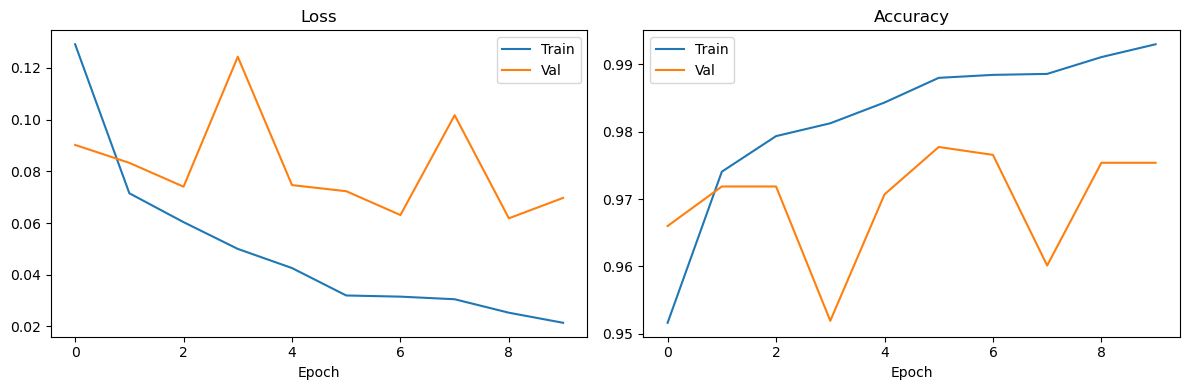

In [16]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

      NORMAL       0.98      0.99      0.98       446
   PNEUMONIA       0.99      0.98      0.98       407

    accuracy                           0.98       853
   macro avg       0.98      0.98      0.98       853
weighted avg       0.98      0.98      0.98       853



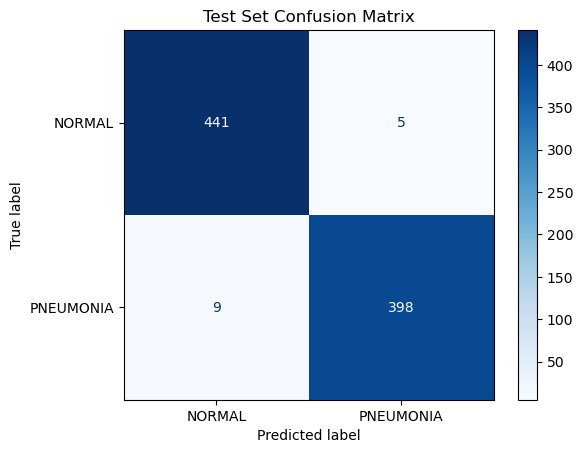

In [17]:
# Test set evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).long().cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Test Set Confusion Matrix")
plt.show()